## THE VRY FIRST STEP IS TO IMPORT THE LIBRARIES WE WILL BE USING IN THIS PROJECT :

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# NOW LOADING DATASET  :

In [23]:
df = pd.read_csv("D:\\csv\\IMDb_Movies_India.csv", encoding = "latin1")
df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


## DISPLAYING FIRST 5 ROWS TO GET A PROPER LOOK OF THE DATASET WE ARE DEALING WITH :

In [24]:
df.head(6)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor


# The dataset contains information about movies including:
* Movie Name
* Genre
* Director
* Actors
* Duration
* Release Year
* Rating

## NOW GETTING SOME BASIC INFORMATION ABOUT THE DATA SET BY USING VARIOUS FUNCTIONS LIKE: 
* INFO
* DESCRIBE
* SHAPE

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [55]:
df.shape

(12407, 10)

In [57]:
df.describe()

,Year,Duration,Rating,Votes
count,12407.000000,12407.000000,12407.000000,12407.000000
mean,1991.884389,130.052873,5.890014,1257.622632
std,21.475627,20.571998,1.086315,9313.179403
min,1917.000000,21.000000,1.100000,5.000000
25%,1978.000000,129.000000,5.600000,35.000000
50%,1994.000000,131.000000,6.000000,55.000000
75%,2010.000000,135.000000,6.300000,110.000000
max,2022.000000,321.000000,10.000000,591417.000000


# Before training the model, the dataset needs to be cleaned:
* Handling missing values
* Removing unnecessary columns
* Converting categorical variables (Genre, Director, Actor) into numerical values using encoding techniques
* And also droping the duplicates if any

* First checking for missing values

In [59]:
df.isnull().sum()

Name           0
Year           0
Duration       0
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2      479
Actor 3     1039
dtype: int64

# HANDLING MISSING VALUES NOW : 
* Which includes replacing some values with different values.
* Filling values with mean and median

In [26]:
df["Year"] = df["Year"].str.replace("[()]" , "", regex = True)
df["Year"] = pd.to_numeric(df["Year"],errors = "coerce")

In [28]:
df["Duration"] = df["Duration"].str.replace("min" , " ") 
df["Duration"] = pd.to_numeric(df["Duration"], errors = "coerce")

In [30]:
df.Votes = df.Votes.str.replace(",","")
df["Votes"] = pd.to_numeric(df.Votes, errors = "coerce")

In [ ]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [ ]:
df["Votes"] = df.Votes.fillna(df.Votes.median())

In [ ]:
df["Duration"] = df["Duration"].fillna(df.Duration.median())

In [ ]:
df.Year.fillna(df.Year.mean(), inplace = True)

* Dropping these subset columns : 

In [ ]:
df.dropna(subset = ["Genre","Director","Actor 1"], inplace = True)

* Checking for duplications:

In [65]:
df.duplicated().sum()

np.int64(0)

* Dropping duplicated now :

In [64]:
df.drop_duplicates(inplace = True)

## NOW CHECKING FOR MISSING VALUES AGAIN: 

In [66]:
df.isnull().sum()

Name           0
Year           0
Duration       0
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2      478
Actor 3     1037
dtype: int64

## EXPLORATORY THE DATA SET

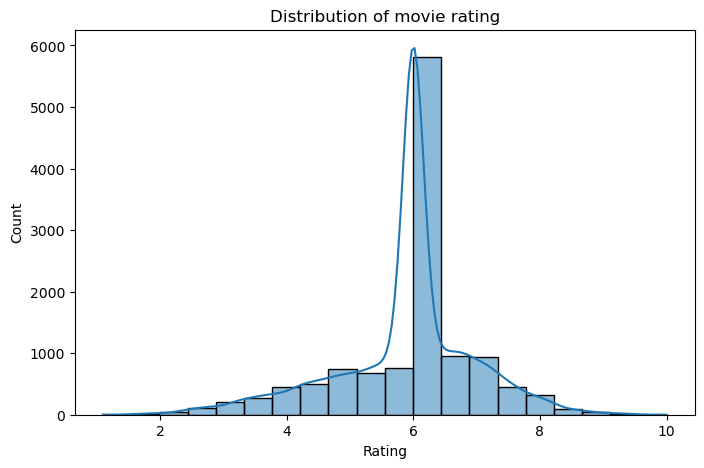

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df.Rating , bins = 20, kde = True)
plt.title("Distribution of movie rating")
plt.show()

* MOVIES RELEASED PER YEAR

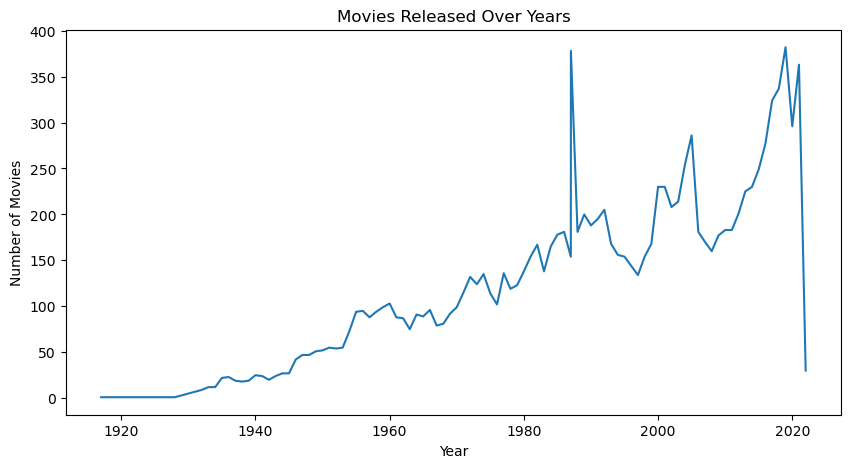

In [41]:
df['Year'].value_counts().sort_index().plot(kind="line", figsize=(10,5))
plt.title("Movies Released Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

## Now we select the important columns from the dataset that will be used for building the prediction model. These features include genre, director, actors, duration, votes, year, and rating.

In [42]:
df_model = df[["Genre","Director","Actor 1","Duration","Votes","Year","Rating"]]

* First the categorical columns such as Genre, Director, and Actor 1 are converted into numerical values using Label Encoding.

In [43]:
le = LabelEncoder()
df_model["Genre"] = le.fit_transform(df_model["Genre"])
df_model["Director"] = le.fit_transform(df_model["Director"])
df_model["Actor 1"] = le.fit_transform(df_model["Actor 1"])

In [67]:
df_model = df_model.dropna()
df_model.isnull().sum()

Genre       0
Director    0
Actor 1     0
Duration    0
Votes       0
Year        0
Rating      0
dtype: int64

* We separate the dataset into:
Features (X) → Input variables
Target (y) → The movie rating we want to predict

In [45]:
X = df_model.drop("Rating",axis=1)
y = df_model["Rating"]

* The dataset is split into training data and testing data.
* Training data is used to train the model, while testing data is used to evaluate it.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

* Now we create and train a Linear Regression model using the training dataset.

In [47]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

* Now we use the trained model to predict movie ratings on the test dataset.

In [52]:
y_pred = model.predict(X_test)

* We evaluate the performance of the model using different evaluation metrics.

In [53]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 0.7262527025130578
Mean Squared Error: 1.095595671865693
R2 Score: 0.06141724133070359


* Finally, we compare the actual movie ratings with the predicted ratings

In [54]:
comparison = pd.DataFrame({
    "Actual Rating": y_test,
    "Predicted Rating": y_pred
})

comparison.head()

,Actual Rating,Predicted Rating
7361,3.9,5.504596
9227,6.4,6.058628
8942,4.4,5.747736
6327,6.0,5.626347
10133,5.1,6.337702


## Conclusion
* This movie dataset was cleaned and prepared using data preprocessing techniques such as handling missing values and encoding categorical variables. A Linear Regression model was then built to predict movie ratings based on features like genre, director, actors, duration, votes, and year. The evaluation metrics showed how well the model performed in predicting ratings, demonstrating the use of basic data analysis and machine learning techniques in Python.